<a href="https://colab.research.google.com/github/srividya-kuntla/Face-liveness-detection-using-CNN/blob/main/CNN_NUAA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Define the path to the zip files in Google Drive
dataset_path = '/content/drive/MyDrive/NUAA'  # Update this to the actual folder containing your zip files
client_zip_path = f"{dataset_path}/ClientRaw.zip"
imposter_zip_path = f"{dataset_path}/ImposterRaw.zip"

# Define the directory to extract the dataset
output_dir = '/content/nuaa_extracted'  # Location to extract data
client_extracted_path = os.path.join(output_dir, 'ClientRaw')
imposter_extracted_path = os.path.join(output_dir, 'Imposter')

In [ ]:
import zipfile

def extract_zip(zip_path, extract_to):
    os.makedirs(extract_to, exist_ok=True)  # Create the folder if it doesn't exist
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)  # Extract all contents
        print(f"Extracted: {zip_path} to {extract_to}")

# Extract the zip files
extract_zip(client_zip_path, client_extracted_path)
extract_zip(imposter_zip_path, imposter_extracted_path)

Extracted: /content/drive/MyDrive/NUAA/ClientRaw.zip to /content/nuaa_extracted/ClientRaw
Extracted: /content/drive/MyDrive/NUAA/ImposterRaw.zip to /content/nuaa_extracted/Imposter


In [ ]:
# Verify the contents of extracted folders
print("ClientRaw Subfolders:", os.listdir(client_extracted_path))
print("Imposter Subfolders:", os.listdir(imposter_extracted_path))

ClientRaw Subfolders: ['ClientRaw']
Imposter Subfolders: ['ImposterRaw']


Visualizing images from ClientRaw...
Subfolders in /content/nuaa_extracted/ClientRaw: ['ClientRaw']
First person folder: /content/nuaa_extracted/ClientRaw/ClientRaw
Person subfolders: ['0010', '0012', '0015', '0007', '0014', '0003', '0008', '0013', '0001', '0002', '0006', '0011', '0009', '0005', '0004']
Images in 0010: ['0010_01_05_03_404.jpg', '0010_01_05_03_141.jpg', '0010_01_05_03_254.jpg']
Trying to read image: /content/nuaa_extracted/ClientRaw/ClientRaw/0010/0010_01_05_03_404.jpg
Trying to read image: /content/nuaa_extracted/ClientRaw/ClientRaw/0010/0010_01_05_03_141.jpg
Trying to read image: /content/nuaa_extracted/ClientRaw/ClientRaw/0010/0010_01_05_03_254.jpg


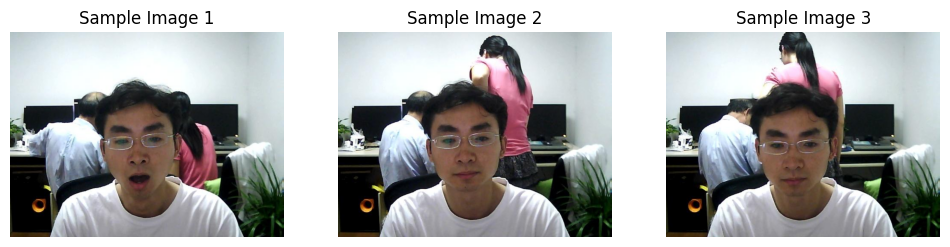

Visualizing images from Imposter...
Subfolders in /content/nuaa_extracted/Imposter: ['ImposterRaw']
First person folder: /content/nuaa_extracted/Imposter/ImposterRaw
Person subfolders: ['0010', '0012', '0016', '0015', '0007', '0014', '0003', '0008', '0001', '0002', '0006', '0011', '0009', '0005', '0004']
Images in 0010: ['0010_01_08_03_280.jpg', '0010_01_01_03_99.jpg', '0010_01_01_03_281.jpg']
Trying to read image: /content/nuaa_extracted/Imposter/ImposterRaw/0010/0010_01_08_03_280.jpg
Trying to read image: /content/nuaa_extracted/Imposter/ImposterRaw/0010/0010_01_01_03_99.jpg
Trying to read image: /content/nuaa_extracted/Imposter/ImposterRaw/0010/0010_01_01_03_281.jpg


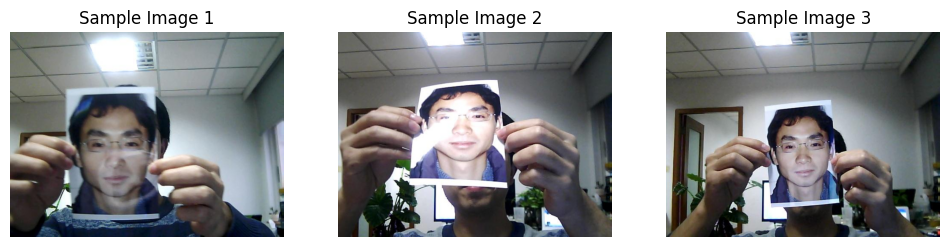

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

def visualize_images(folder_path, num_images=3):
    """
    Visualize a few sample images from a folder with nested subfolders.
    """
    subfolders = os.listdir(folder_path)
    print(f"Subfolders in {folder_path}: {subfolders}")

    if len(subfolders) == 0:
        print("No subfolders found. Please check the extracted directory.")
        return

    # Select the first subfolder
    first_person_folder = os.path.join(folder_path, subfolders[0])  # Select the first person's folder
    print(f"First person folder: {first_person_folder}")

    if not os.path.isdir(first_person_folder):
        print(f"ERROR: {first_person_folder} is not a directory.")
        return

    # Get images from the first person's folder
    person_folders = os.listdir(first_person_folder)
    print(f"Person subfolders: {person_folders}")

    for person_folder in person_folders:
        # Get image files from the folder (filtering out non-image files)
        person_folder_path = os.path.join(first_person_folder, person_folder)
        images = [
            img for img in os.listdir(person_folder_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ][:num_images]

        print(f"Images in {person_folder}: {images}")

        if len(images) == 0:
            print(f"No images found in {person_folder}.")
            continue

        # Plot images
        plt.figure(figsize=(12, 6))
        for i, img_name in enumerate(images):
            img_path = os.path.join(person_folder_path, img_name)
            print(f"Trying to read image: {img_path}")
            img = cv2.imread(img_path)
            if img is None:
                print(f"Failed to load image: {img_path}")
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for visualization

            plt.subplot(1, num_images, i + 1)
            plt.imshow(img)
            plt.title(f"Sample Image {i + 1}")
            plt.axis("off")
        plt.show()
        break  # Show images from the first person's folder only for now

# Visualize images from ClientRaw and Imposter datasets
print("Visualizing images from ClientRaw...")
visualize_images(client_extracted_path)

print("Visualizing images from Imposter...")
visualize_images(imposter_extracted_path)


Visualizing and preprocessing images from ClientRaw...
Subfolders in /content/nuaa_extracted/ClientRaw: ['ClientRaw']
First person folder: /content/nuaa_extracted/ClientRaw/ClientRaw
Person subfolders: ['0010', '0012', '0015', '0007', '0014', '0003', '0008', '0013', '0001', '0002', '0006', '0011', '0009', '0005', '0004']


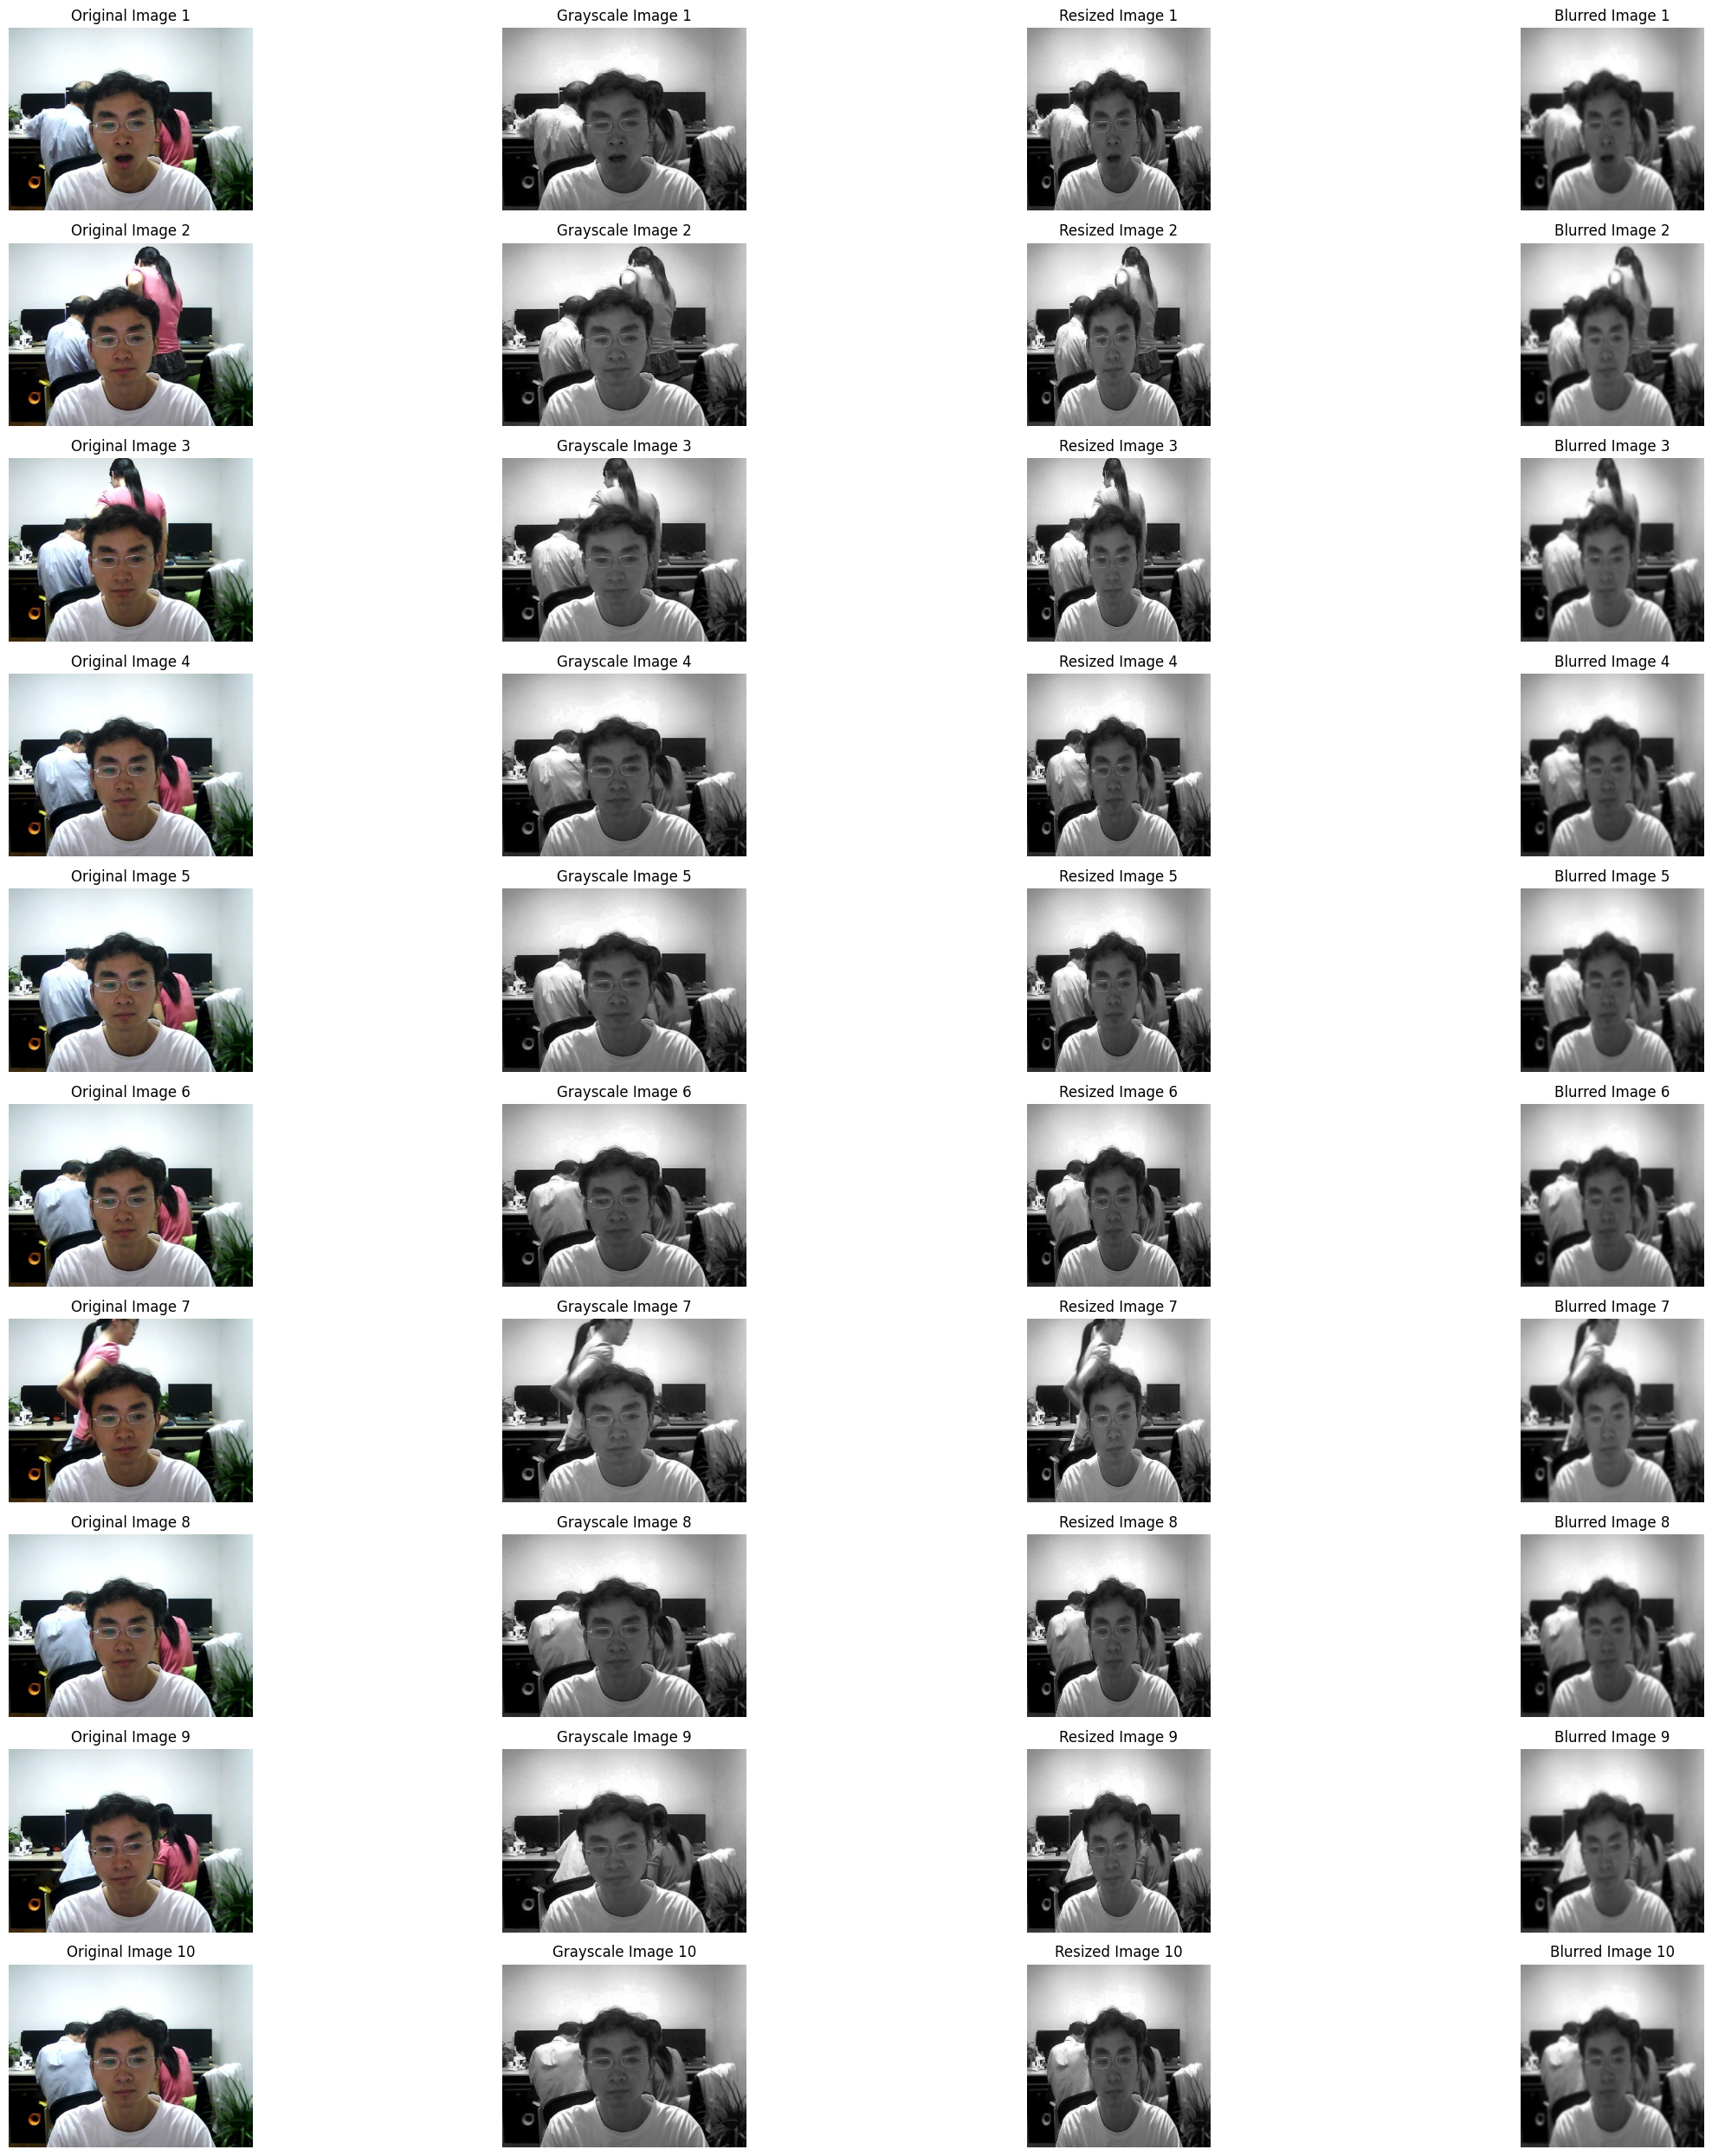

Visualizing and preprocessing images from Imposter...
Subfolders in /content/nuaa_extracted/Imposter: ['ImposterRaw']
First person folder: /content/nuaa_extracted/Imposter/ImposterRaw
Person subfolders: ['0010', '0012', '0016', '0015', '0007', '0014', '0003', '0008', '0001', '0002', '0006', '0011', '0009', '0005', '0004']


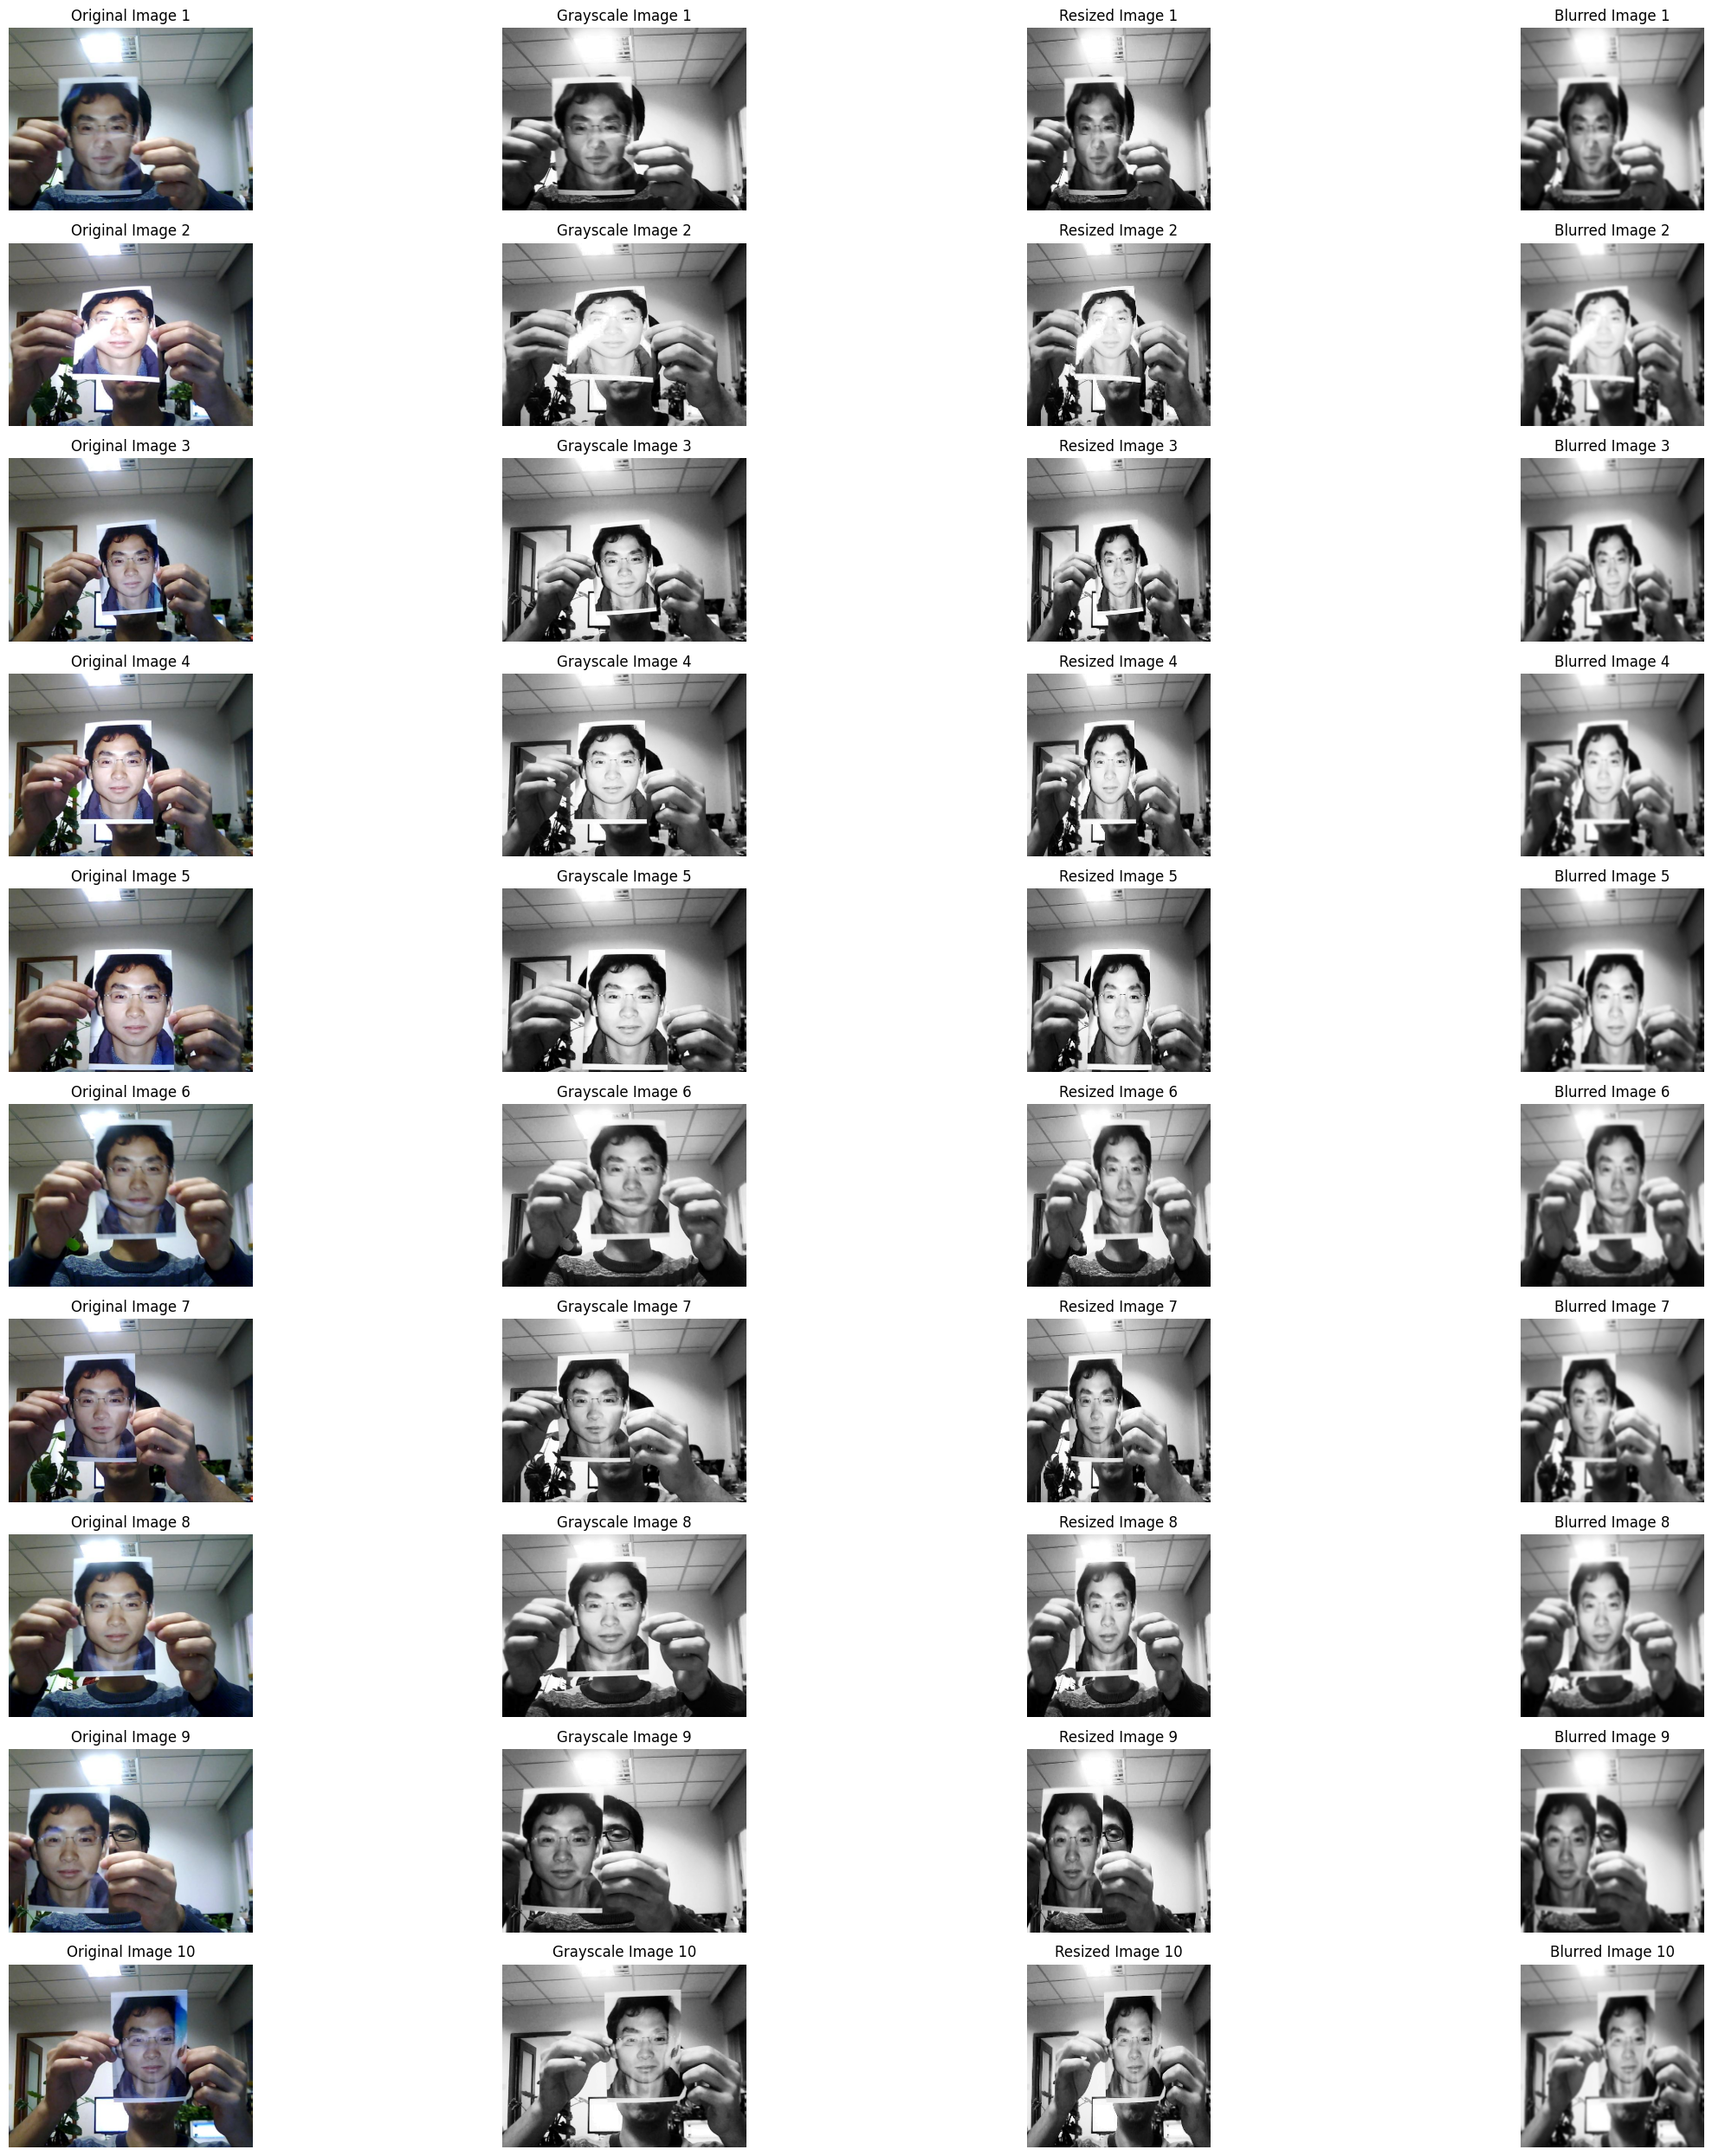

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to apply multiple preprocessing techniques (grayscale, histogram equalization, resizing, and blur)
def preprocess_image(image_path, resize_dim=(224, 224), apply_blur=True):
    # Read the image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Failed to load image: {image_path}")
        return None, None

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply histogram equalization
    gray = cv2.equalizeHist(gray)

    # Resize the image to a consistent size
    resized = cv2.resize(gray, resize_dim)

    # Apply Gaussian blur
    if apply_blur:
        blurred = cv2.GaussianBlur(resized, (5, 5), 0)
    else:
        blurred = resized

    return img, gray, resized, blurred

# Function to visualize real vs preprocessed images
def display_real_vs_preprocessed(image_paths, num_images=10):
    if not image_paths:
        print("No images to display.")
        return

    fig, axes = plt.subplots(num_images, 4, figsize=(25, 25))  # 4 columns to display 4 versions

    for i in range(num_images):
        if i >= len(image_paths):  # Stop if there are fewer images than requested
            break

        img_path = image_paths[i]

        # Load and preprocess the image (get both original and all preprocessed versions)
        original_img, grayscale_img, resized_img, blurred_img = preprocess_image(img_path)

        if original_img is None:
            continue

        # Display the original image
        axes[i, 0].imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for proper display
        axes[i, 0].set_title(f"Original Image {i+1}")
        axes[i, 0].axis('off')

        # Display the grayscale image
        axes[i, 1].imshow(grayscale_img, cmap='gray')  # Grayscale image
        axes[i, 1].set_title(f"Grayscale Image {i+1}")
        axes[i, 1].axis('off')

        # Display the resized image
        axes[i, 2].imshow(resized_img, cmap='gray')  # Resized image
        axes[i, 2].set_title(f"Resized Image {i+1}")
        axes[i, 2].axis('off')

        # Display the blurred image
        axes[i, 3].imshow(blurred_img, cmap='gray')  # Blurred image
        axes[i, 3].set_title(f"Blurred Image {i+1}")
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.show()

# Function to visualize and preprocess images from a folder (ClientRaw or Imposter)
def preprocess_and_visualize_images(folder_path, num_images=10):
    subfolders = os.listdir(folder_path)
    print(f"Subfolders in {folder_path}: {subfolders}")

    if len(subfolders) == 0:
        print("No subfolders found. Please check the extracted directory.")
        return

    # Select the first subfolder
    first_person_folder = os.path.join(folder_path, subfolders[0])  # Select the first person's folder
    print(f"First person folder: {first_person_folder}")

    if not os.path.isdir(first_person_folder):
        print(f"ERROR: {first_person_folder} is not a directory.")
        return

    # Get images from the first person's folder
    person_folders = os.listdir(first_person_folder)
    print(f"Person subfolders: {person_folders}")

    # Get image files from the folder (filtering out non-image files)
    image_paths = []
    for person_folder in person_folders:
        person_folder_path = os.path.join(first_person_folder, person_folder)
        images = [
            img for img in os.listdir(person_folder_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        for img_name in images:
            image_paths.append(os.path.join(person_folder_path, img_name))

        if len(image_paths) >= num_images:
            break  # Stop after collecting the required number of images

    # Display the real vs preprocessed images
    display_real_vs_preprocessed(image_paths, num_images=num_images)

# Visualize and preprocess images from ClientRaw and Imposter datasets
print("Visualizing and preprocessing images from ClientRaw...")
preprocess_and_visualize_images(client_extracted_path, num_images=10)

print("Visualizing and preprocessing images from Imposter...")
preprocess_and_visualize_images(imposter_extracted_path, num_images=10)





In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Paths to preprocessed dataset
client_path = '/content/nuaa_extracted/ClientRaw/ClientRaw'
imposter_path = '/content/nuaa_extracted/Imposter/ImposterRaw'

In [ ]:
import os
import cv2
import numpy as np

def load_images_and_labels(path, label):
    images = []
    labels = []

    # Walk through all subdirectories
    for root, dirs, files in os.walk(path):
        for file in files:
            # Check for valid image extensions
            if file.endswith(('.jpg', '.png', '.jpeg')):
                file_path = os.path.join(root, file)

                # Load and preprocess the image
                img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)  # Load as grayscale
                img = cv2.resize(img, (224, 224))  # Resize to 224x224
                images.append(img)
                labels.append(label)

    # Convert to numpy arrays
    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)

    # Add channel dimension for grayscale
    if len(images.shape) == 3:
        images = images[..., np.newaxis]

    return images, labels


In [ ]:
# Load live and spoofed images
client_images, client_labels = load_images_and_labels(client_path, label=1)
imposter_images, imposter_labels = load_images_and_labels(imposter_path, label=0)

In [ ]:
# Combine live and spoofed data
X = np.concatenate((client_images, imposter_images), axis=0)
y = np.concatenate((client_labels, imposter_labels), axis=0)

In [ ]:
# Normalize the images to [0, 1]
X = X / 255.0
X = X.reshape(-1, 224, 224, 1)  # Add channel dimension (grayscale)

In [ ]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

In [ ]:
# Build CNN Model
def create_cnn(input_shape=(224, 224, 1)):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')  # Binary classification (live/spoof)
    ])
    return model

In [ ]:
model = create_cnn()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Train the model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=20
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


176/176 ━━━━━━━━━━━━━━━━━━━━ 24s 131ms/step - accuracy: 0.9995 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 2.3579e-04
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 131ms/step - accuracy: 0.9980 - loss: 0.0058 - val_accuracy: 1.0000 - val_loss: 5.2325e-10
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 24s 129ms/step - accuracy: 0.9966 - loss: 0.0169 - val_accuracy: 0.8070 - val_loss: 4.4921
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 128ms/step - accuracy: 0.9987 - loss: 0.0096 - val_accuracy: 0.9993 - val_loss: 0.0670
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 24s 132ms/step - accuracy: 0.9987 - loss: 0.0056 - val_accuracy: 0.8454 - val_loss: 7.4150
Epoch 6/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 24s 134ms/step - accuracy: 0.9966 - loss: 0.0147 - val_accuracy: 0.9886 - val_loss: 0.6186
Epoch 7/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 137ms/step - accuracy: 0.9973 - loss: 0.0201 - val_accuracy: 0.9915 - val_loss: 0.1307
Epoch 8/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 23s 129ms/step - accuracy: 0.9986 - loss: 0.01

In [ ]:

print("Classification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.64      0.78      1150
           1       0.38      1.00      0.55       254

    accuracy                           0.70      1404
   macro avg       0.69      0.82      0.66      1404
weighted avg       0.89      0.70      0.74      1404



44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


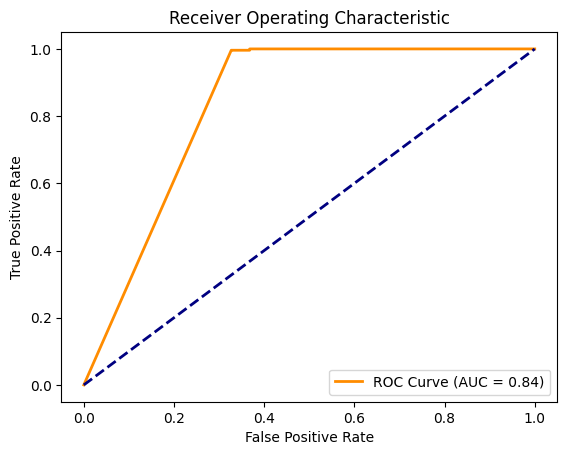

In [ ]:
# ROC-AUC Curve
y_pred_proba = model.predict(X_test).ravel()
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.show()